# 1 - Bibliotecas

In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

import json
from google.colab import files
from google.cloud import bigquery
from google.cloud.bigquery import SchemaField

# 2 - Carregando os dados

In [ ]:
# Caminho para o arquivo .xlsx
caminho_do_arquivo = 'data/promotions_products_data.csv'

# Ler o arquivo csv para um DataFrame
df_prom_prod = pd.read_csv(caminho_do_arquivo)

df_prom_prod

,cod_ciclo,cod_ano,cod_canal,cod_agrupador_sap_material,cod_regional_agrupador,cod_uf,des_categoria_material,des_subcategoria_material,des_marca_material,des_tier,des_mecanica_consumidor,des_mecanica_rev,des_promocao_publico,vlr_desconto_real,vlr_rbv_tabela_so_tt,vlr_rbv_real_so_tt,vlr_preco_base,vlr_preco_venda,vlr_preco_tabela,vlr_desconto_real2
0,201916,2019.0,Anon2,13488.501226,Anon3,Anon3,Anon2,Anon2,Anon2,Anon2,Anon12,Anon1,Anon1,8495.257045,19999.884318,11504.627273,30.211268,17.328639,30.211268,7343.64
1,202308,2023.0,Anon1,15699.180973,Anon2,Anon1,Anon1,Anon1,Anon2,Anon2,Anon5,Anon4,Anon3,6.940910,76.118643,69.177734,23.169014,21.056338,23.169014,6.00
2,202309,2023.0,Anon1,19406.783582,Anon3,Anon2,Anon1,Anon1,Anon5,Anon3,Anon3,Anon1,Anon2,0.000000,35378.973671,35378.973671,126.690141,126.690141,126.690141,0.00
3,202303,2023.0,Anon2,19412.567674,Anon2,Anon1,Anon1,Anon1,Anon5,Anon3,Anon10,Anon1,Anon1,19.943547,9968.881588,9948.938041,80.915493,80.776995,80.915493,17.24
4,202201,2022.0,Anon1,23459.118042,Anon1,Anon1,Anon1,Anon1,Anon5,Anon3,Anon3,Anon1,Anon2,196.740086,2856.762760,2660.022674,31.619718,29.373239,31.619718,170.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,202311,2023.0,Anon2,27037.157003,Anon3,Anon2,Anon1,Anon1,Anon5,Anon3,Anon2,Anon1,Anon1,6033.605571,30039.678867,24006.073296,56.267606,44.964789,56.267606,5215.69
19498,202310,2023.0,Anon2,27385.359308,Anon3,Anon2,Anon1,Anon3,Anon2,Anon2,Anon6,Anon1,Anon1,15071.260006,69454.444496,54383.184489,21.056338,16.622066,21.056338,13028.20
19499,202310,2023.0,Anon2,27385.359308,Anon3,Anon3,Anon1,Anon3,Anon2,Anon2,Anon6,Anon1,Anon1,4460.749156,20580.375735,16119.626579,21.056338,16.394366,21.056338,3856.05
19500,202311,2023.0,Anon2,27385.359308,Anon3,Anon2,Anon1,Anon3,Anon2,Anon2,Anon3,Anon1,Anon2,0.000000,1487.321272,1487.321272,21.056338,21.056338,21.056338,0.00


In [41]:
df_prom_prod

,cod_ciclo,cod_ano,cod_canal,cod_agrupador_sap_material,cod_regional_agrupador,cod_uf,des_categoria_material,des_subcategoria_material,des_marca_material,des_tier,des_mecanica_consumidor,des_mecanica_rev,des_promocao_publico,vlr_desconto_real,vlr_rbv_tabela_so_tt,vlr_rbv_real_so_tt,vlr_preco_base,vlr_preco_venda,vlr_preco_tabela,vlr_desconto_real2
0,201916,2019.0,Anon2,13488.501226,Anon3,Anon3,Anon2,Anon2,Anon2,Anon2,Anon12,Anon1,Anon1,8495.257045,19999.884318,11504.627273,30.211268,17.328639,30.211268,7343.64
1,202308,2023.0,Anon1,15699.180973,Anon2,Anon1,Anon1,Anon1,Anon2,Anon2,Anon5,Anon4,Anon3,6.940910,76.118643,69.177734,23.169014,21.056338,23.169014,6.00
2,202309,2023.0,Anon1,19406.783582,Anon3,Anon2,Anon1,Anon1,Anon5,Anon3,Anon3,Anon1,Anon2,0.000000,35378.973671,35378.973671,126.690141,126.690141,126.690141,0.00
3,202303,2023.0,Anon2,19412.567674,Anon2,Anon1,Anon1,Anon1,Anon5,Anon3,Anon10,Anon1,Anon1,19.943547,9968.881588,9948.938041,80.915493,80.776995,80.915493,17.24
4,202201,2022.0,Anon1,23459.118042,Anon1,Anon1,Anon1,Anon1,Anon5,Anon3,Anon3,Anon1,Anon2,196.740086,2856.762760,2660.022674,31.619718,29.373239,31.619718,170.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,202311,2023.0,Anon2,27037.157003,Anon3,Anon2,Anon1,Anon1,Anon5,Anon3,Anon2,Anon1,Anon1,6033.605571,30039.678867,24006.073296,56.267606,44.964789,56.267606,5215.69
19498,202310,2023.0,Anon2,27385.359308,Anon3,Anon2,Anon1,Anon3,Anon2,Anon2,Anon6,Anon1,Anon1,15071.260006,69454.444496,54383.184489,21.056338,16.622066,21.056338,13028.20
19499,202310,2023.0,Anon2,27385.359308,Anon3,Anon3,Anon1,Anon3,Anon2,Anon2,Anon6,Anon1,Anon1,4460.749156,20580.375735,16119.626579,21.056338,16.394366,21.056338,3856.05
19500,202311,2023.0,Anon2,27385.359308,Anon3,Anon2,Anon1,Anon3,Anon2,Anon2,Anon3,Anon1,Anon2,0.000000,1487.321272,1487.321272,21.056338,21.056338,21.056338,0.00


# 3 - Análise Exploratória de Dados

In [42]:
print("\n--- INFO BÁSICA ---")
print(f"Registros: {df_prom_prod.shape[0]}")
print(f"Colunas: {df_prom_prod.shape[1]}")


--- INFO BÁSICA ---
Registros: 19502
Colunas: 20


## 3.1 Duplicados

In [43]:
print("\n🔎 Linhas duplicadas:", df_prom_prod.duplicated().sum())


🔎 Linhas duplicadas: 200


Remove-se os duplicados, já que não agregam valor analítico.

In [44]:
df_prom_prod = df_prom_prod.drop_duplicates()
print("Após remover duplicados:", df_prom_prod.shape)

Após remover duplicados: (19302, 20)


## 3.2 - Valores Ausentes

In [45]:
print("\n🔎 Valores ausentes por coluna:")
missing = df_prom_prod.isnull().sum().sort_values(ascending=False)
missing_pct = (missing/len(df_prom_prod))*100
print(pd.DataFrame({"missing": missing, "pct": missing_pct}))


🔎 Valores ausentes por coluna:
                            missing       pct
vlr_desconto_real                15  0.077712
vlr_desconto_real2               15  0.077712
cod_ano                          12  0.062170
cod_ciclo                         0  0.000000
cod_agrupador_sap_material        0  0.000000
cod_canal                         0  0.000000
cod_regional_agrupador            0  0.000000
cod_uf                            0  0.000000
des_marca_material                0  0.000000
des_tier                          0  0.000000
des_categoria_material            0  0.000000
des_subcategoria_material         0  0.000000
des_mecanica_rev                  0  0.000000
des_mecanica_consumidor           0  0.000000
vlr_rbv_tabela_so_tt              0  0.000000
des_promocao_publico              0  0.000000
vlr_rbv_real_so_tt                0  0.000000
vlr_preco_base                    0  0.000000
vlr_preco_venda                   0  0.000000
vlr_preco_tabela                  0  0.000000


As colunas `vlr_desconto_real` e `vlr_desconto_real2` serão preenchidas com a mediana.

In [46]:
df_prom_prod['vlr_desconto_real'] = df_prom_prod['vlr_desconto_real'].fillna(df_prom_prod['vlr_desconto_real'].median())
df_prom_prod['vlr_desconto_real2'] = df_prom_prod['vlr_desconto_real2'].fillna(df_prom_prod['vlr_desconto_real2'].median())

/tmp/ipython-input-1944899265.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prom_prod['vlr_desconto_real'] = df_prom_prod['vlr_desconto_real'].fillna(df_prom_prod['vlr_desconto_real'].median())
/tmp/ipython-input-1944899265.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prom_prod['vlr_desconto_real2'] = df_prom_prod['vlr_desconto_real2'].fillna(df_prom_prod['vlr_desconto_real2'].median())


Observou-se que os primeiros quatro digitos da coluna `cod_ciclo` são exatamente o ano na coluna `cod_ano`.

Como apenas a coluna `cod_ano` tem valores ausentes, eles serão preenchidos com os quatro primeiros dígitos da coluna `cod_ciclo` correspondente.

In [47]:
df_prom_prod["cod_ciclo"] = df_prom_prod["cod_ciclo"].astype(str)

# Criar coluna auxiliar com os 4 primeiros dígitos de cod_ciclo
df_prom_prod["ano_from_ciclo"] = df_prom_prod["cod_ciclo"].str[:4].astype(int)

# Preencher valores ausentes em cod_ano usando ano_from_ciclo
df_prom_prod["cod_ano"] = df_prom_prod["cod_ano"].fillna(df_prom_prod["ano_from_ciclo"])

# Converter para inteiro
df_prom_prod["cod_ano"] = df_prom_prod["cod_ano"].astype(int)

# Remover coluna auxiliar
df_prom_prod = df_prom_prod.drop(columns = ["ano_from_ciclo"])

/tmp/ipython-input-668137045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prom_prod["cod_ciclo"] = df_prom_prod["cod_ciclo"].astype(str)
/tmp/ipython-input-668137045.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prom_prod["ano_from_ciclo"] = df_prom_prod["cod_ciclo"].str[:4].astype(int)
/tmp/ipython-input-668137045.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [48]:
print("\n🔎 Valores ausentes por coluna:")
missing = df_prom_prod.isnull().sum().sort_values(ascending=False)
missing_pct = (missing/len(df_prom_prod))*100
print(pd.DataFrame({"missing": missing, "pct": missing_pct}))


🔎 Valores ausentes por coluna:
                            missing  pct
cod_ciclo                         0  0.0
cod_ano                           0  0.0
cod_canal                         0  0.0
cod_agrupador_sap_material        0  0.0
cod_regional_agrupador            0  0.0
cod_uf                            0  0.0
des_categoria_material            0  0.0
des_subcategoria_material         0  0.0
des_marca_material                0  0.0
des_tier                          0  0.0
des_mecanica_consumidor           0  0.0
des_mecanica_rev                  0  0.0
des_promocao_publico              0  0.0
vlr_desconto_real                 0  0.0
vlr_rbv_tabela_so_tt              0  0.0
vlr_rbv_real_so_tt                0  0.0
vlr_preco_base                    0  0.0
vlr_preco_venda                   0  0.0
vlr_preco_tabela                  0  0.0
vlr_desconto_real2                0  0.0


## 3.3 - Tipos

In [49]:
df_prom_prod.dtypes

,0
cod_ciclo,object
cod_ano,int64
cod_canal,object
cod_agrupador_sap_material,float64
cod_regional_agrupador,object
cod_uf,object
des_categoria_material,object
des_subcategoria_material,object
des_marca_material,object
des_tier,object


A coluna `cod_agrupador_sap_material` está como tipo float64. Vamos transformar para o tipo object.

In [50]:
df_prom_prod["cod_agrupador_sap_material"] = df_prom_prod["cod_agrupador_sap_material"].astype(str)

## 3.4 Variáveis categóricas principais (sem valor analítico)

In [52]:
print("\n📊 Colunas categóricas com dominância:")
for col in df_prom_prod.select_dtypes(include = "object").columns:
    top_freq = df_prom_prod[col].value_counts(normalize = True, dropna = False).values[0]
    if top_freq > 0.90:  # mais de 90% do mesmo valor
        print(f"- {col}: {top_freq:.1%} de dominância")


📊 Colunas categóricas com dominância:


Todas as variáveis categóricas parecem informativas.

## 3.5 Outliers

In [53]:
num_cols = df_prom_prod.select_dtypes(include=["number"]).columns
outliers = {}
for col in num_cols:
    q1, q3 = df_prom_prod[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_count = ((df_prom_prod[col] < lower) | (df_prom_prod[col] > upper)).sum()
    if outlier_count > 0:
        outliers[col] = outlier_count

print("\n⚠️ Possíveis outliers detectados:")
for col, count in outliers.items():
    print(f"- {col}: {count} registros fora do IQR")


⚠️ Possíveis outliers detectados:
- vlr_desconto_real: 3246 registros fora do IQR
- vlr_rbv_tabela_so_tt: 2098 registros fora do IQR
- vlr_rbv_real_so_tt: 2083 registros fora do IQR
- vlr_preco_base: 286 registros fora do IQR
- vlr_preco_venda: 576 registros fora do IQR
- vlr_preco_tabela: 286 registros fora do IQR
- vlr_desconto_real2: 3246 registros fora do IQR


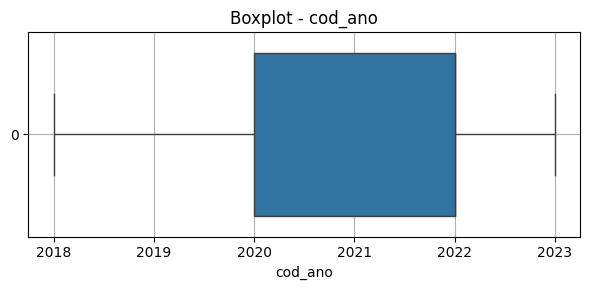

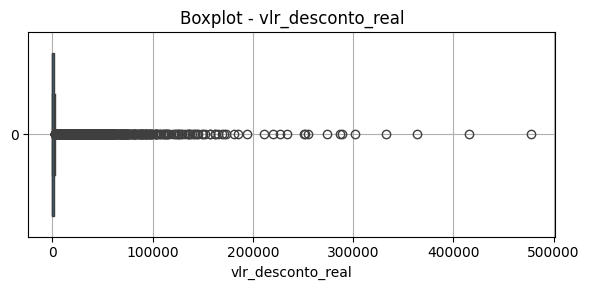

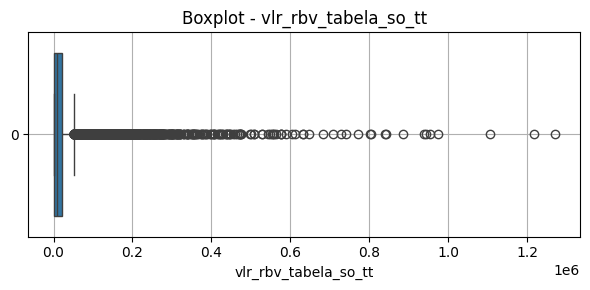

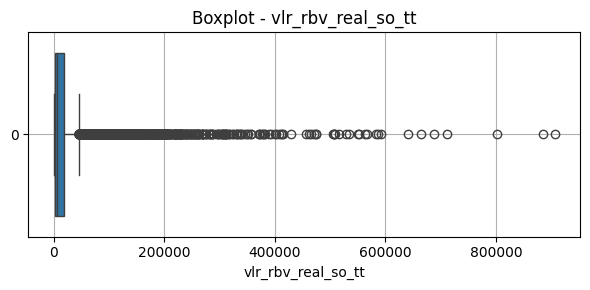

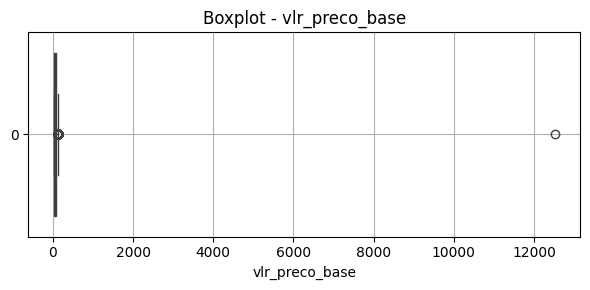

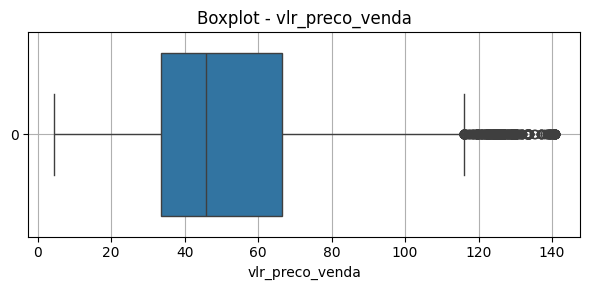

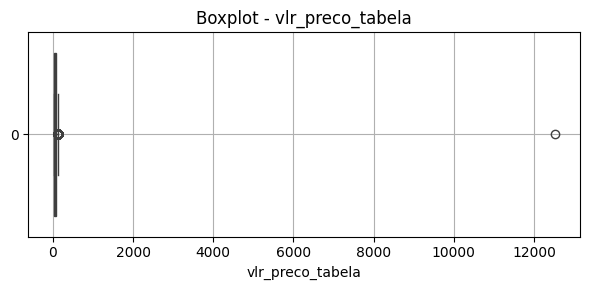

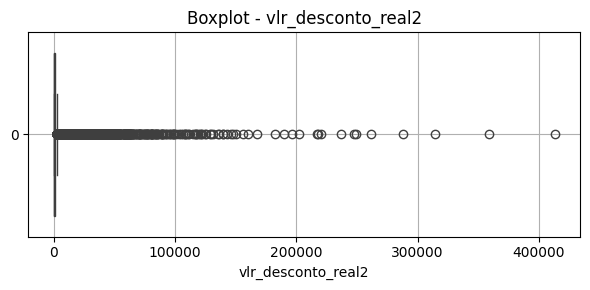

In [54]:
# Boxplots para inspeção visual
for col in num_cols:
    plt.figure(figsize = (6,3))
    sns.boxplot(x = df_prom_prod[col])
    plt.title(f"Boxplot - {col}")

    # Formatar o eixo Y para mostrar números sem notação científica e com separador de milhar
    formatter = mticker.StrMethodFormatter('{x:,.0f}') # Formato: número com separador de milhar, sem casas decimais
    plt.gca().yaxis.set_major_formatter(formatter)

    plt.grid(True)
    plt.tight_layout() # Ajusta o layout para não cortar os rótulos
    plt.show()

Vamos manter os valores originais pois descontos e preços extremos podem ser legítimos (promoções agressivas, erros de cadastro ou campanhas específicas).

# 4 - Subindo os dados no BigQuery

In [55]:
from google.colab import auth
auth.authenticate_user()

In [56]:
uploaded = files.upload()

# Lê o conteúdo do arquivo
secrets_content = uploaded['secrets.json']
secrets = json.loads(secrets_content)

# Extrai as informações
project_id = secrets['project_id']
dataset_id = secrets['dataset_id']

Saving secrets.json to secrets.json


In [58]:
df_prom_prod

,cod_ciclo,cod_ano,cod_canal,cod_agrupador_sap_material,cod_regional_agrupador,cod_uf,des_categoria_material,des_subcategoria_material,des_marca_material,des_tier,des_mecanica_consumidor,des_mecanica_rev,des_promocao_publico,vlr_desconto_real,vlr_rbv_tabela_so_tt,vlr_rbv_real_so_tt,vlr_preco_base,vlr_preco_venda,vlr_preco_tabela,vlr_desconto_real2
0,201916,2019,Anon2,13488.5012262274,Anon3,Anon3,Anon2,Anon2,Anon2,Anon2,Anon12,Anon1,Anon1,8495.257045,19999.884318,11504.627273,30.211268,17.328639,30.211268,7343.64
1,202308,2023,Anon1,15699.1809726528,Anon2,Anon1,Anon1,Anon1,Anon2,Anon2,Anon5,Anon4,Anon3,6.940910,76.118643,69.177734,23.169014,21.056338,23.169014,6.00
2,202309,2023,Anon1,19406.7835824349,Anon3,Anon2,Anon1,Anon1,Anon5,Anon3,Anon3,Anon1,Anon2,0.000000,35378.973671,35378.973671,126.690141,126.690141,126.690141,0.00
3,202303,2023,Anon2,19412.5676738698,Anon2,Anon1,Anon1,Anon1,Anon5,Anon3,Anon10,Anon1,Anon1,19.943547,9968.881588,9948.938041,80.915493,80.776995,80.915493,17.24
4,202201,2022,Anon1,23459.118041738,Anon1,Anon1,Anon1,Anon1,Anon5,Anon3,Anon3,Anon1,Anon2,196.740086,2856.762760,2660.022674,31.619718,29.373239,31.619718,170.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,202311,2023,Anon2,27037.1570033779,Anon3,Anon2,Anon1,Anon1,Anon5,Anon3,Anon2,Anon1,Anon1,6033.605571,30039.678867,24006.073296,56.267606,44.964789,56.267606,5215.69
19498,202310,2023,Anon2,27385.3593077599,Anon3,Anon2,Anon1,Anon3,Anon2,Anon2,Anon6,Anon1,Anon1,15071.260006,69454.444496,54383.184489,21.056338,16.622066,21.056338,13028.20
19499,202310,2023,Anon2,27385.3593077599,Anon3,Anon3,Anon1,Anon3,Anon2,Anon2,Anon6,Anon1,Anon1,4460.749156,20580.375735,16119.626579,21.056338,16.394366,21.056338,3856.05
19500,202311,2023,Anon2,27385.3593077599,Anon3,Anon2,Anon1,Anon3,Anon2,Anon2,Anon3,Anon1,Anon2,0.000000,1487.321272,1487.321272,21.056338,21.056338,21.056338,0.00


In [57]:
df_prom_prod.dtypes

,0
cod_ciclo,object
cod_ano,int64
cod_canal,object
cod_agrupador_sap_material,object
cod_regional_agrupador,object
cod_uf,object
des_categoria_material,object
des_subcategoria_material,object
des_marca_material,object
des_tier,object


In [59]:
schema = [
    SchemaField("cod_ciclo", "STRING"),
    SchemaField("cod_ano", "INTEGER"),
    SchemaField("cod_canal", "STRING"),
    SchemaField("cod_agrupador_sap_material", "STRING"),
    SchemaField("cod_regional_agrupador", "STRING"),
    SchemaField("cod_uf", "STRING"),
    SchemaField("des_categoria_material", "STRING"),
    SchemaField("des_subcategoria_material", "STRING"),
    SchemaField("des_marca_material", "STRING"),
    SchemaField("des_tier", "STRING"),
    SchemaField("des_mecanica_consumidor", "STRING"),
    SchemaField("des_mecanica_rev", "STRING"),
    SchemaField("des_promocao_publico", "STRING"),
    SchemaField("vlr_desconto_real", "FLOAT"),
    SchemaField("vlr_rbv_tabela_so_tt", "FLOAT"),
    SchemaField("vlr_rbv_real_so_tt", "FLOAT"),
    SchemaField("vlr_preco_base", "FLOAT"),
    SchemaField("vlr_preco_venda", "FLOAT"),
    SchemaField("vlr_preco_tabela", "FLOAT"),
    SchemaField("vlr_desconto_real2", "FLOAT")
]

In [64]:
client = bigquery.Client(project=project_id)
table_ref = client.dataset(dataset_id).table("tab_promocoes_produtos")
job_config = bigquery.LoadJobConfig(
    schema = schema,
    write_disposition = "WRITE_TRUNCATE",
)

job = client.load_table_from_dataframe(
    df_prom_prod, table_ref, job_config = job_config
)
job.result()

print("DataFrame carregado")

DataFrame carregado
